In [ ]:
# day 75

import pandas as pd
df = pd.read_csv("compressed_data (2).csv")

print("🔹 First 5 rows:")
print(df.head())

print("\n🔹 Columns:")
print(df.columns)

print("\n🔹 Dataset Info:")
print(df.info())

print("\n🔹 Summary Statistics:")
print(df.describe())

🔹 First 5 rows:
   Order Date Product Name     Category Region  Quantity  Sales  Profit
0  2024-12-31      Printer       Office  North         4   3640  348.93
1  2022-11-27        Mouse  Accessories   East         7   1197  106.53
2  2022-05-11       Tablet  Electronics  South         5   5865  502.73
3  2024-03-16        Mouse  Accessories  South         2    786  202.87
4  2022-09-10        Mouse  Accessories   West         1    509  103.28

🔹 Columns:
Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

🔹 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int6

In [ ]:
# Day 76 — Data Cleaning

df.columns = df.columns.str.lower().str.replace(" ", "_")

df['order_date'] = pd.to_datetime(df['order_date'])

print("Missing Values:\n", df.isnull().sum())

df = df.drop_duplicates()

print("\nData Types:\n", df.dtypes)

print("\nUnique Categories:", df['category'].unique())
print("Unique Regions:", df['region'].unique())

Missing Values:
 order_date      0
product_name    0
category        0
region          0
quantity        0
sales           0
profit          0
dtype: int64

Data Types:
 order_date      datetime64[ns]
product_name            object
category                object
region                  object
quantity                 int64
sales                    int64
profit                 float64
dtype: object

Unique Categories: ['Office' 'Accessories' 'Electronics']
Unique Regions: ['North' 'East' 'South' 'West']


In [ ]:
# Day 77 — Repeat Behavior Analysis

repeat_customers = df.groupby(['product_name', 'region']).size().reset_index(name='orders')

repeat_customers = repeat_customers[repeat_customers['orders'] > 1]
repeat_customers = repeat_customers.sort_values(by='orders', ascending=False)

print(repeat_customers.head(10))
print("Total Repeat Segments:", len(repeat_customers))

   product_name region  orders
2        Camera  South     105
39       Tablet   West     104
23        Mouse   West     100
32   Smartwatch   East     100
17      Monitor  North     100
6    Headphones  South      99
27      Printer   West      98
8      Keyboard   East      98
19      Monitor   West      98
26      Printer  South      97
Total Repeat Segments: 40


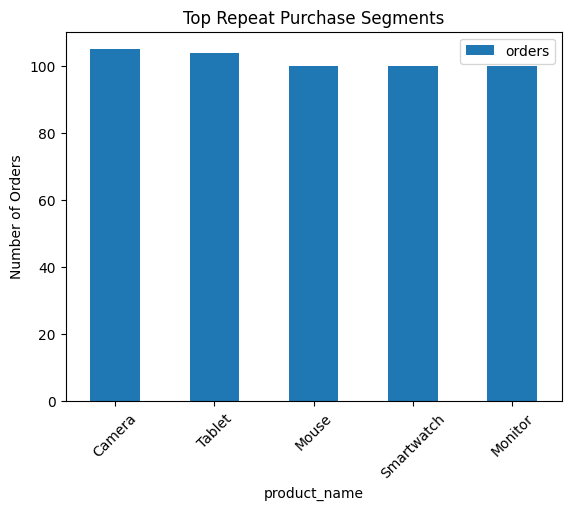

In [20]:
import matplotlib.pyplot as plt

top_repeat = repeat_customers.head(5)

top_repeat.plot(kind='bar', x='product_name', y='orders')
plt.title("Top Repeat Purchase Segments")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [4]:
import pandas as pd

df = pd.read_csv("compressed_data (2).csv")
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Day 78 — Purchase Frequency Analysis
purchase_freq = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False)

print(purchase_freq.head(10))

product_name
Monitor       1876
Smartwatch    1807
Camera        1795
Mouse         1753
Printer       1734
Tablet        1733
Keyboard      1684
Laptop        1658
Smartphone    1617
Headphones    1604
Name: quantity, dtype: int64


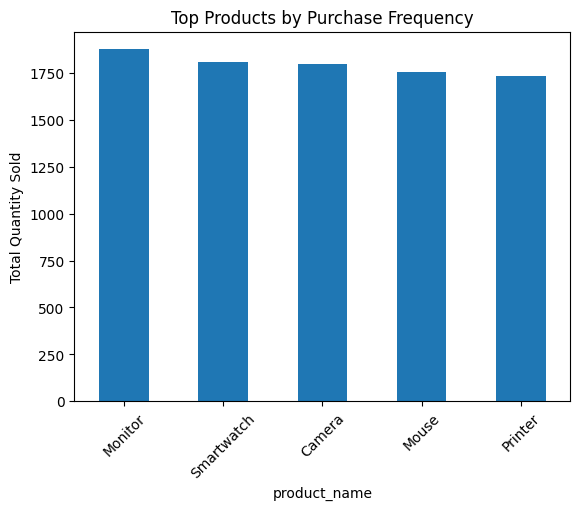

In [5]:
import matplotlib.pyplot as plt

top_products = purchase_freq.head(5)

top_products.plot(kind='bar')
plt.title("Top Products by Purchase Frequency")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [6]:
# Day 79
# top revenue products
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False)

print(top_products.head(10))

product_name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: sales, dtype: int64


In [ ]:
# Category wise revenue
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
print(category_sales)

category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: sales, dtype: int64


In [8]:
# region wise revenue
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
print(region_sales)

region
West     2844450
East     2675110
South    2659548
North    2488773
Name: sales, dtype: int64


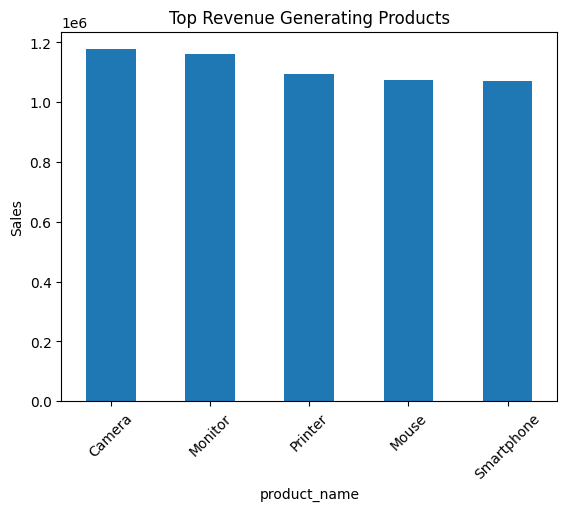

In [9]:
# top products chart 
import matplotlib.pyplot as plt

top_products.head(5).plot(kind='bar')
plt.title("Top Revenue Generating Products")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

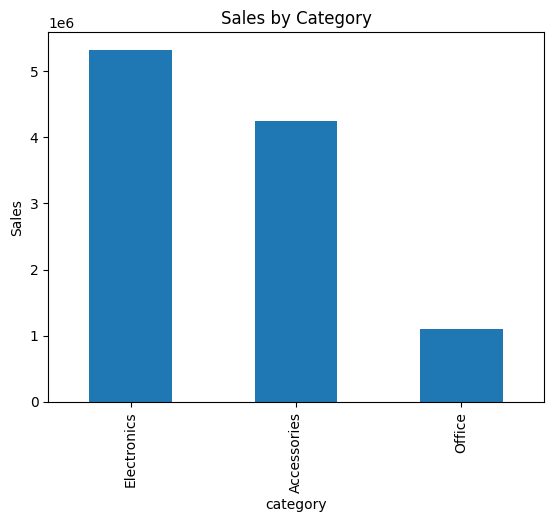

In [12]:
# category revenue chart
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

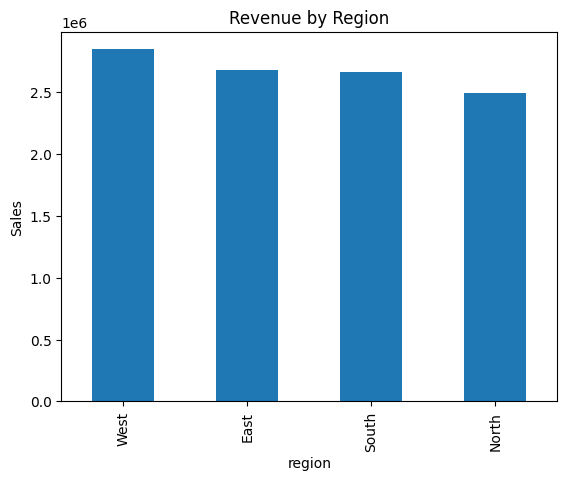

In [11]:
# region revenue chart
region_sales.plot(kind='bar')
plt.title("Revenue by Region")
plt.ylabel("Sales")
plt.show()